# Gibbs bot profile simulation analysis

This notebook reads the simulated PsyNet export directly and reports the completed-participant profile distribution plus profile stability, response validity, and a lightweight behavior comparison. The profiles are simulated bot sanity checks, not human behavior estimates.

In [1]:
from pathlib import Path
import json
import zipfile

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 50
EXPORT_ZIP = Path('../simulated_data.zip')

def read_export_csv(name):
    with zipfile.ZipFile(EXPORT_ZIP) as zf:
        with zf.open(f'simulated_data/regular/data/{name}') as f:
            return pd.read_csv(f)

bots = read_export_csv('Bot.csv')
trials = read_export_csv('CustomTrial.csv')
responses = read_export_csv('Response.csv')
print(f'Read {len(bots)} bots, {len(trials)} color trials, and {len(responses)} responses from {EXPORT_ZIP}.')

Read 10 bots, 70 color trials, and 130 responses from ../simulated_data.zip.


## Reported participant profile distribution

Counts below come from completed simulated participants only: `complete == True` and `aborted == False` in `Bot.csv`.

In [2]:
completed = bots[(bots['complete'] == True) & (bots['aborted'] == False)].copy()
profile_counts = (
    completed.groupby('bot_profile', dropna=False)
    .agg(completed_participants=('id', 'count'))
    .reset_index()
    .sort_values('bot_profile')
)
profile_counts

,bot_profile,completed_participants
0,normal_rgb,5
1,random,5


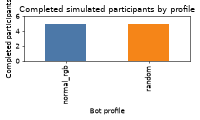

In [3]:
ax = profile_counts.plot.bar(x='bot_profile', y='completed_participants', legend=False, color=['#4c78a8', '#f58518'], figsize=(4, 2.5))
ax.set_title('Completed simulated participants by profile')
ax.set_xlabel('Bot profile')
ax.set_ylabel('Completed participants')
ax.set_ylim(0, max(profile_counts['completed_participants']) + 1)
plt.tight_layout()

## Trial-level stability and response validity

`CustomTrial.csv` contains one row per finalized color trial, including participant id, profile, target, active channel, starting RGB vector, and submitted response.

In [4]:
color_trials = trials[trials['finalized'] == True].copy()
color_trials['answer'] = color_trials['answer'].astype(int)

def starting_active_channel(row):
    vector = json.loads(row['initial_vector']) if isinstance(row['initial_vector'], str) else row['initial_vector']
    return vector[int(row['active_index'])]

color_trials['starting_active_channel'] = color_trials.apply(starting_active_channel, axis=1)
color_trials['abs_distance_from_start'] = (color_trials['answer'] - color_trials['starting_active_channel']).abs()
stability = (
    color_trials.groupby('participant_id')
    .agg(
        bot_profile=('bot_profile', 'first'),
        n_profiles=('bot_profile', 'nunique'),
        n_color_trials=('id', 'count'),
        response_min=('answer', 'min'),
        response_max=('answer', 'max'),
    )
    .reset_index()
)
stability['profile_stable'] = stability['n_profiles'] == 1
stability['all_7_color_trials'] = stability['n_color_trials'] == 7
stability['responses_in_range'] = (stability['response_min'] >= 0) & (stability['response_max'] <= 255)
stability

,participant_id,bot_profile,n_profiles,n_color_trials,response_min,response_max,profile_stable,all_7_color_trials,responses_in_range
0,1,normal_rgb,1,7,6,192,True,True,True
1,2,normal_rgb,1,7,77,199,True,True,True
2,3,normal_rgb,1,7,94,250,True,True,True
3,4,random,1,7,42,244,True,True,True
4,5,random,1,7,18,237,True,True,True
5,6,random,1,7,2,241,True,True,True
6,7,normal_rgb,1,7,16,238,True,True,True
7,8,random,1,7,18,255,True,True,True
8,9,normal_rgb,1,7,0,240,True,True,True
9,10,random,1,7,45,240,True,True,True


In [5]:
random_count = int(profile_counts.loc[profile_counts['bot_profile'] == 'random', 'completed_participants'].iloc[0])
normal_count = int(profile_counts.loc[profile_counts['bot_profile'] == 'normal_rgb', 'completed_participants'].iloc[0])
checks = pd.DataFrame([
    {'check': 'completed participants', 'observed': len(completed), 'expected': 10, 'passed': len(completed) == 10},
    {'check': 'random profile count', 'observed': random_count, 'expected': 5, 'passed': random_count == 5},
    {'check': 'normal_rgb profile count', 'observed': normal_count, 'expected': 5, 'passed': normal_count == 5},
    {'check': 'stable profile for every participant', 'observed': bool(stability['profile_stable'].all()), 'expected': True, 'passed': bool(stability['profile_stable'].all())},
    {'check': 'seven color trials per participant', 'observed': bool(stability['all_7_color_trials'].all()), 'expected': True, 'passed': bool(stability['all_7_color_trials'].all())},
    {'check': 'responses are integers in [0, 255]', 'observed': bool(stability['responses_in_range'].all()), 'expected': True, 'passed': bool(stability['responses_in_range'].all())},
])
checks

,check,observed,expected,passed
0,completed participants,10,10,True
1,random profile count,5,5,True
2,normal_rgb profile count,5,5,True
3,stable profile for every participant,True,True,True
4,seven color trials per participant,True,True,True
5,"responses are integers in [0, 255]",True,True,True


## Lightweight behavioral comparison

The random profile should spread responses across the valid channel range, while the normal profile should stay closer to the presented active-channel value.

In [6]:
behavior = (
    color_trials.groupby('bot_profile')
    .agg(
        n_color_trials=('id', 'count'),
        response_min=('answer', 'min'),
        response_max=('answer', 'max'),
        response_variance=('answer', 'var'),
        mean_abs_distance_from_start=('abs_distance_from_start', 'mean'),
        median_abs_distance_from_start=('abs_distance_from_start', 'median'),
    )
    .reset_index()
    .sort_values('bot_profile')
)
behavior.round(3)

,bot_profile,n_color_trials,response_min,response_max,response_variance,mean_abs_distance_from_start,median_abs_distance_from_start
0,normal_rgb,35,0,250,5774.634,14.571,12.0
1,random,35,2,255,6118.970,94.229,87.0


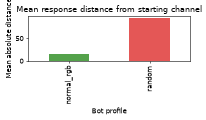

In [7]:
ax = behavior.plot.bar(x='bot_profile', y='mean_abs_distance_from_start', legend=False, color=['#54a24b', '#e45756'], figsize=(4, 2.5))
ax.set_title('Mean response distance from starting channel')
ax.set_xlabel('Bot profile')
ax.set_ylabel('Mean absolute distance')
plt.tight_layout()

## Interpretation

The simulated export contains 10 completed bot participants with a balanced reported distribution: five `random` and five `normal_rgb`. Every participant has one stable profile across seven finalized color trials, and all submitted color-channel responses are valid integers in the inclusive range 0 to 255. The behavior summary is a simulation sanity check only.